# Apartment Rental Data Analysis

What better model to evaluate and train than the large dataset of apartment rental prices? Apartment rental prices allow a wide bredth of data to be harvested, and contain a great number of features that lend themsleves well vectorization into True/False vectors. Additionally, finding data to determine if we might be overfitting or underfitting our data should be very easy, and testing it on data from websites should be very easy. It can even be turned into a simple form which can be used by prospective landlords to determine what price they should list thier apartments at.
<br><br>
In this notebook, I will analyze the data in a number of ways for insights. For example, what is the average rent per state? What is the ratio of bedrooms to bathrooms in each state? How does this correlate with the average price? Using the **seaborn** graphing library, we can create interesting charts for these questions as well. 
<br><br>
Additionally, I will train a model using Random Forest Decision Trees to take a list of features from the user and suggest a reasonable rent price for the unit. This can then be easily be deployed to an array of places where this servie would be useful -- i.e. consulting, first time landlords, etc. It would be a small task to create an HTML/PHP form which takes a list of amenities, location, bathrooms, and bedrooms to generate a suggested rental price.
<br><br> 
**Hypothesis**: The price of an apartment is based on its features,  bedrooms, bathrooms, and location to varying degrees, and a Random Forest Decision Tree Regression Model can be used to model and anticipate this price.
<br><br>
**Data source**: The data comes from this Kaggle dataset: https://www.kaggle.com/datasets/shashanks1202/apartment-rent-data

In [1]:
import numpy as np # linear algebra

import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.metrics import mean_absolute_error #used in the calculation of mean absolute error for model gauging
from sklearn.model_selection import train_test_split #used to create a training and test set from a massive set
from sklearn.ensemble import RandomForestRegressor #the ML we will use for training

from wordcloud import WordCloud #for generating wordclouds
import matplotlib.pyplot as plt #matlabplot is used a lot
import seaborn as sns #make my charts beautiful

import scipy.stats as stats #miscellaneous stats functions
from scipy.stats import linregress #linear regression analysis functions

import warnings #to filter warnings, like the lineplot warning that it will no longer accept inf values (not relevant)
import operator #used by leaf node analysis function

# Input data files are available in the read-only "../input/" directory

import os #work with files in our docker image
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#options
pd.options.display.float_format = "{:,.2f}".format #set floats to behave like dollars
warnings.filterwarnings("ignore", "use_inf_as_na") #ignore use inf as na errors in sns.lineplot 

/kaggle/input/apartment-rent-data/apartments_for_rent_classified_100K/apartments_for_rent_classified_100K.csv
/kaggle/input/apartment-rent-data/apartments_for_rent_classified_10K/apartments_for_rent_classified_10K.csv


# Functions

### get_mae
Calculates the mean absolute error of a given set of validation and training data using a leaf node<br>
**In**:
- **max_leaf_nodes** - a variable which declares the number of leaf nodes in the model
- **train_X, val_X** - features of the dataset, one for training and the other for validation
- **val_y** - the validation data is the variable we are predicting. There is only one data set for this, because it is the same for validation and training<br>

**Out**:
- **mae** - the mean absolute error

### calc_best_leaf_nodes
Tests a list of leaf nodes to find the one with the lowest MAE and returns it.<br>
**In**: 
- **leaf_nodes** - expects a list of values to test. I declare this in the variables section as value and then pass it each time
- **train_X, val_X** - features of the dataset, one for training and the other for validation
- **val_y** - the validation data is the variable we are predicting. There is only one data set for this, because it is the same for validation and training<br>

**Out**:
- **best leaf node** - the lowest valued MAE key:value pair value 

### make_dummies
Creates dummy columns from a column of strings, and then removes the original column if remove=True(df, col)<br>
**In**:
- **df**: dataframe to update and return
- **col**: column to be removed -- have not tested with a list of values, but it should work
- **remove**: bool value representing whether to drop the original column in the dataframe<br>

**Out**:
- **df**: updated dataframe

### regression_analysis
This is a simple function I found in my research which runs a regression analysis against all columns and prints out the statistical relationships.<br>
**In**:
- **data_for_regression**: a dataframe of columns to be compared
- **column_name**: the column we wish to compare against

**Out**:
- **Returns no variable. Prints the results of regression analysis.**

In [2]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    '''
    Takes a training set, validation set, and max number of leaf nodes and determines the mean absolute
    error, allowing evaluation of the accuracy of the model. This function is intended specifically for use
    on models which have a random forest or decision tree model
    
    '''
    model = RandomForestRegressor(max_leaf_nodes=max_leaf_nodes, random_state=23)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)

def calc_best_leaf_nodes(leaf_nodes, train_X, val_X, train_y, val_y):
    '''
    Takes a list of values for leaf nodes to be testing, and training and validation data as arguements.
    
    Compare MAE with differing values of max_leaf_nodes and return the leaf node with the lowest mae,
    this can allow us to automate the process of selecting an apropriate number of leaf nodes.    
    '''
    leaf_dict = {}
    for max_leaf_nodes in leaf_nodes:
        my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
        print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %f" %(max_leaf_nodes, my_mae))
        leaf_dict.update({max_leaf_nodes:my_mae})
    return min(leaf_dict.items(), key=operator.itemgetter(1))[0]

def make_dummies(df, col, remove=True):
    '''
    begin process of updating categorical data into boolean category/column data
    first, update to_remove to remove all special characters
    then split into seperate dummy columns
    finally, add columns back to the dataframe and drop the original column (no longer needed)
    
    in: dataframe to update, column to make dummies of
    out: updated dataframe with the original column remove, and the dummy columns added to the end
    '''
    df[col] = df[col].str.strip()
    df = pd.concat([df, df[col].str.get_dummies(sep=',')], axis=1)
    if remove==True:
        df = df.drop([col], axis=1)
    return df

def regression_analysis(data_for_regression, column_name):
    '''
    takes a dataframe and a column name and runs regression analysis against every other column in the
    dataframe to assist in analyzing correlations and causation likelihood
    '''
    return data_for_regression.apply(lambda vals: linregress(data_for_regression[column_name], vals), result_type='expand').rename(index={0: 'slope', 1: 'intercept', 2: 'rvalue', 3:'p-value', 4:'stderr'})

# Variables

#### apts
Dataframe containing the entire large dataset for training and analysis. This will be conditioned earlier in the process than small_apts.

#### small_apts
Smaller dataset provided by the orignal author which can be used to analyze the effectiveness of the model. By running it as a secondary validation step we can determine if we have over or underfit our model. It will additionally introduce a level of variance in the results that we can determine what our MAE (mean absolute error) on untrained data is.

#### features
This is a list which will contain the features we want to use to build our model. These will be used quite often in training, and are filled from the columns in apts later in the process.

**note from version 12 forward**: removed 'price display' from features and import. This datapoint will have a 1:1 correlation with the price, and is really just a more complicated version of price for conditioning.

#### y
This is the price column of the dataframe, which is ultimately what we want our model to be able to predict

In [3]:
#Load dataframe
#This data frame has some interesting aspects to it, so I will be explicit in which columns I want,
#and what to do with values in those columns. because of its size, we must also declare dtype to 
#improve the performance and avoid a warning
apts = pd.read_csv('/kaggle/input/apartment-rent-data/apartments_for_rent_classified_100K/apartments_for_rent_classified_100K.csv', sep=";",  encoding='cp1252' ,
                   usecols=['id','amenities', 'bathrooms' , 'bedrooms', 'fee' , 'has_photo', 'pets_allowed' , 'price' , 'square_feet', 'cityname' , 'state', 'latitude', 'longitude' , 'source' , 'time'] ,
                  dtype={'amenities':'string', 'bathrooms':'Float32' , 'bedrooms':'Float32',  
                        'fee':'string', 'has_photo':'string' ,'pets_allowed':'string', 'price': 'Float64', 
                        'square_feet':'Int64' , 'latitude':'Float64', 'longitude':'Float64' , 'source':'string', 'time':'Int64'} , index_col = 0)
small_apts = pd.read_csv('/kaggle/input/apartment-rent-data/apartments_for_rent_classified_10K/apartments_for_rent_classified_10K.csv', sep=";",  encoding='cp1252' ,
                   usecols=['id','amenities', 'bathrooms' , 'bedrooms', 'fee' , 'has_photo', 'pets_allowed' , 'price' , 'square_feet', 'cityname' , 'state', 'latitude', 'longitude' , 'source' , 'time'] ,
                  dtype={'amenities':'string', 'bathrooms':'Float32' , 'bedrooms':'Float32',
                        'fee':'string', 'has_photo':'string' ,'pets_allowed':'string', 'price': 'Float64', 
                        'square_feet':'Int64' , 'latitude':'Float64', 'longitude':'Float64' , 'source':'string', 'time':'string'} , index_col = 0)

features = []
y = apts.price

#We will need to convert the categorical values into something we can parse in analysis -- this is a prime candidate for 

apts

,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude,source,time
id,,,,,,,,,,,,,,
5668640009,<NA>,1.00,1.00,No,Thumbnail,Cats,"2,195.00",542,Redondo Beach,CA,33.85,-118.38,RentLingo,1577360355
5668639818,<NA>,1.50,3.00,No,Thumbnail,"Cats,Dogs","1,250.00",1500,Newport News,VA,37.09,-76.49,RentLingo,1577360340
5668639686,<NA>,2.00,3.00,No,Thumbnail,<NA>,"1,395.00",1650,Raleigh,NC,35.82,-78.64,RentLingo,1577360332
5668639659,<NA>,1.00,2.00,No,Thumbnail,"Cats,Dogs","1,600.00",820,Vacaville,CA,38.36,-121.97,RentLingo,1577360330
5668639374,<NA>,1.00,1.00,No,Thumbnail,"Cats,Dogs",975.00,624,Albuquerque,NM,35.10,-106.61,RentLingo,1577360308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5121219946,"Gym,Parking,Patio/Deck,Playground,Storage,Wood...",1.00,1.00,No,Yes,<NA>,780.00,605,Houston,TX,29.62,-95.20,RentDigs.com,1544185770
5121219696,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gym...",2.00,2.00,No,Yes,"Cats,Dogs",813.00,921,Jacksonville,FL,30.23,-81.76,RentDigs.com,1544185750
5121219420,"Garbage Disposal,Refrigerator",1.00,1.00,No,Yes,"Cats,Dogs","1,325.00",650,San Diego,CA,32.74,-117.09,RentDigs.com,1544185729


# Data Conditioning

We should analyze our data and make sure that it 'makes sense'. In addition to removing outliers, and fixing NaN values and other problems with the data, another one of the things we need to do is address missing values. We should get the data ready for analysis and interpretation, but while we do that we can lay some of the ground work in training a model.

### Handle Nulls, Update States

Replace all null and not a number values with 0 to prevent errors. Additionally, we need to remove odd state entries, like one rogue '0' that I found while analyzing this data. Furthermore, I change state and cityname to be strings instead of objects. There isn't a huge foundational reason for this, but they should be marginally faster this way, and I understand and trust strings more than objects in dataframes.

Before

<class 'pandas.core.frame.DataFrame'>
Index: 99492 entries, 5668640009 to 5121218844
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amenities     83448 non-null  string 
 1   bathrooms     99429 non-null  Float32
 2   bedrooms      99368 non-null  Float32
 3   fee           99492 non-null  string 
 4   has_photo     99492 non-null  string 
 5   pets_allowed  39068 non-null  string 
 6   price         99491 non-null  Float64
 7   square_feet   99492 non-null  Int64  
 8   cityname      99190 non-null  object 
 9   state         99190 non-null  object 
 10  latitude      99467 non-null  Float64
 11  longitude     99467 non-null  Float64
 12  source        99492 non-null  string 
 13  time          99492 non-null  Int64  
dtypes: Float32(2), Float64(3), Int64(2), object(2), string(5)
memory usage: 11.3+ MB
None

After:

<class 'pandas.core.frame.DataFrame'>
Index: 99007 entries, 5668640009 to 5121218844
D

<Axes: xlabel='price'>

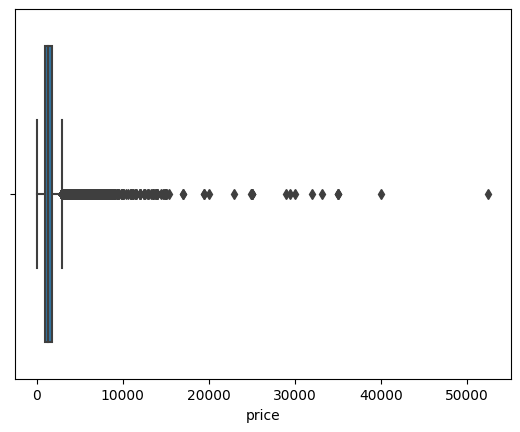

In [4]:
print("Before\n")
print(apts.info())

#create 'noamenities' as a category, for use in later dummy creation
apts['amenities'] = apts["amenities"].fillna("noamenities")

#create 'none' for 'pets_allowed' for use in later dummy creation
apts["pets_allowed"] = apts["pets_allowed"].fillna("None")

#Instead of interpreting weird results, like no number of bathrooms or no numbers of bedrooms, we will drop those data points
#this also includes 'state = 0' an odd result that I've seen come up later in analysis
apts = apts[apts['bathrooms'].notna()]
apts = apts[apts['bedrooms'].notna()]
apts = apts[apts['price'].notna()]
apts = apts[apts['latitude'].notna()]
apts = apts[apts['longitude'].notna()]
apts = apts[apts['cityname'].notna()]
apts = apts[apts['state'].notna()]
apts = apts[apts.state != 0]

#change datatype of state to string, no real reason other than i don't trust objects
apts['state'] = apts['state'].astype("string")
apts['cityname'] = apts['cityname'].astype("string")

#Check to make sure we no longer have a difference between entries and nulls
print("\nAfter:\n")
print(apts.info())
print(apts.describe())

#create a boxplot of our price values to see if we have a lot of outliers that may change our interpretations
sns.boxplot(x=apts["price"])

## Outlier Analysis

Based on our Box-plot there are a lot of outliers in our data, so we should address that next. First, lets take a look at the distribution of our data -- it looks fairly normal, but has a very large tail end and very narrow center band. This could be drastically improved by reducing the number of extreme values in our data.

<Axes: ylabel='Density'>

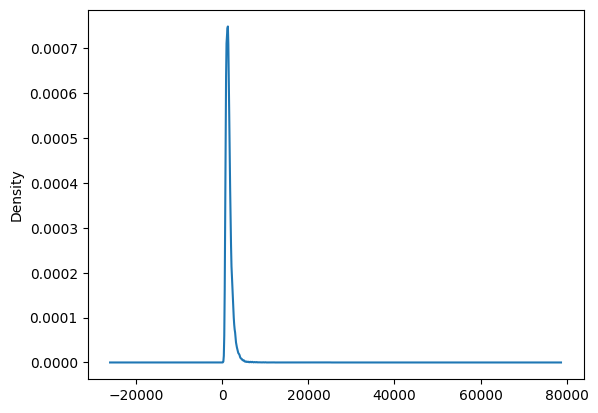

In [5]:
apts['price'].plot(kind='kde')

#### Filter Out Values > 4000

We will use the value of USD 4000 as a maximum monthly rent cut off. This is largely arbitrary, but amounts to a total of USD 48000 a year in rent. This is a very large number, but high end apartments in places like New York, DC, and Hawaii are not out of the question, and I  would prefer to include these higher end entries than to remove them.

<Axes: xlabel='price'>

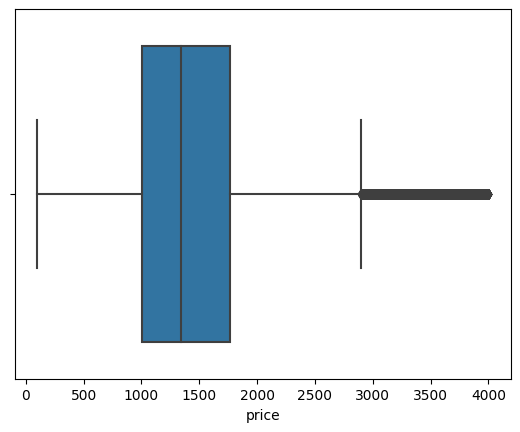

In [6]:
apts = apts[apts.price < 4000]
sns.boxplot(x=apts["price"])

<Axes: ylabel='Density'>

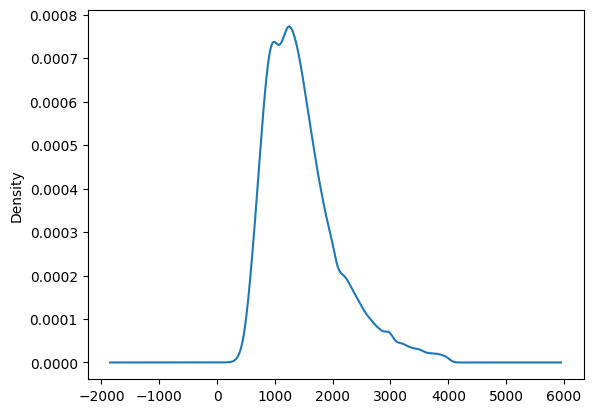

In [7]:
apts['price'].plot(kind='kde')

Based on the data distribution and the box plot, I feel it is a reasonable filter of the data to cut off the price brackets at 4000. This includes some of the higher outliers, but excludes the very few but heavily weighted 'resort' style rents which heavily weight the other end of the scale.

# Data Analysis and Interpretations

## State Breakdown

One thing we should analyze about our data, is how often are certain states represented? What are the average prices of rent in those states? To do this, first lets create a dataframe for this specific analysis called **state_apts**. Then we will group all the data in that dataframe by state. Then we can calculate the pricce average, sort it by those valules and assign it to the **state_means** dataframe. Then we will create a count of the state entries from the value_counts() function of the state column in the apts dataframe and call this **state_counts**. 

In [8]:
# create dataframe grouped by
state_apts = apts.groupby('state')

#get the mean of the grouped states prices and make into dataframe then sort
state_means = state_apts['price'].mean()
state_means = state_means.reset_index()
state_means = state_means.sort_values(['price'])

#get the value counts for the states, and create a dataframe
state_counts = apts.state.value_counts()
state_counts = state_counts.reset_index()

display(state_means)
display(state_counts)

,state,price
50,WY,791.75
32,NM,844.04
49,WV,871.77
25,MS,874.16
2,AR,874.37
41,SD,887.65
16,KS,915.00
29,NE,933.35
1,AL,944.97
28,ND,946.28


,state,count
0,TX,11233
1,CA,9525
2,VA,8273
3,NC,6294
4,CO,6271
5,FL,5632
6,MD,5256
7,OH,4898
8,MA,4894
9,GA,4749


### Chart the Data

So, we have the raw data printed out and we can look at it, but its sort of hard to interpret in this long form style. Let's put it into an interesting graphic so that we can draw some conclusions a little quicker without using too much math! The best way I thought of to present this data is to create a bar graph of the average price of rent by state, and then put the number of entries we had from that state as a dot using a secondary y-axis.

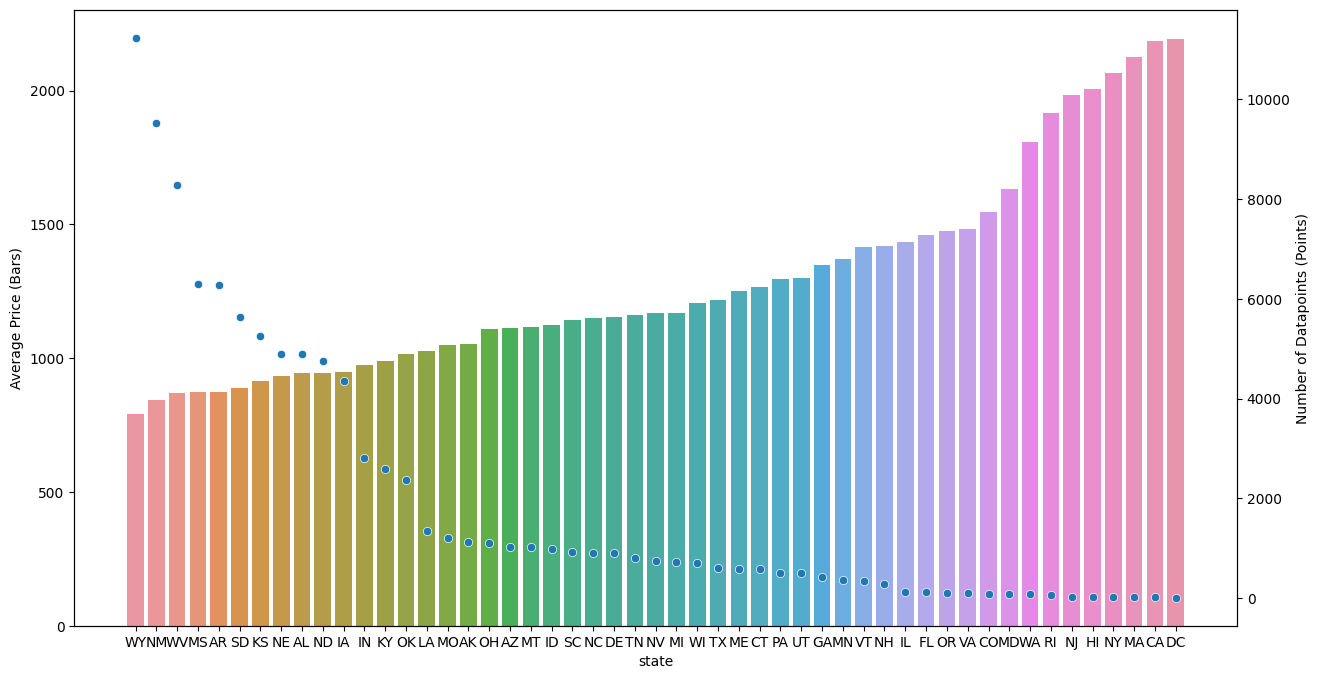

In [9]:
#create subplots and set figsize to be larger
fig, ax1 = plt.subplots(figsize=(15,8))

#create BAR plot
sns.barplot(x = 'state', y = 'price',data = state_means, ax=ax1)
ax1.set_ylabel('Average Price (Bars)')

#Create a duplicate y-axis for mapping
ax2 = ax1.twinx()

#create SCATTER plot
sns.scatterplot(x = 'state', y = 'count', data = state_counts,  ax=ax2)
ax2.set_ylabel('Number of Datapoints (Points)')

#show the plot
plt.show()

### Analysis of State Price Data

One of the things that stands out about this data is that there appears to be a significant correlation between the price and the number of entries in our dataset. Hawaii has a very small number of small datapoints and has the highest average price. An interesting interpretation of this is that we can see a correlation between the number of apartments in the dataset (to be interpreted as the number of apartments available) and the price of those apartments. This follows supply and demand principles, the less apartments available, the higher that the rents charged will be.

### Bathrooms and Bedrooms By State

The next datapoint I'm interested in understanding is the average number of bedrooms and bathrooms in an apartment in each state. To do this, I will chart the average bathrooms and average bedrooms on one axis, and put the price as a line on the chart overlaying this information. 

To accomplish this I created a few new dataframes. **bathrooms** is a dataframe of just the apts dataframe grouped by state with the bathrooms column, sorted by the number of bathrooms on average. **bedrooms** is the same style of dataframe, but for bedrooms data. **bedrooms_with_price** is a merge with the apts data to add the prices by state, and **bedrooms_bathrooms_price** is another merge to create a dataframe containing price, average bathrooms, and average bedrooms grouped by state.

There isn't a lot that we can interpret from this, except that if you're interested in the most bedrooms in an apartment, West Virginia offers the highest average number of bedrooms and near the upper end of bathrooms for one of the lowest prices! So, after this, we should investigate if there is a link between bathrooms and bedrooms and price.

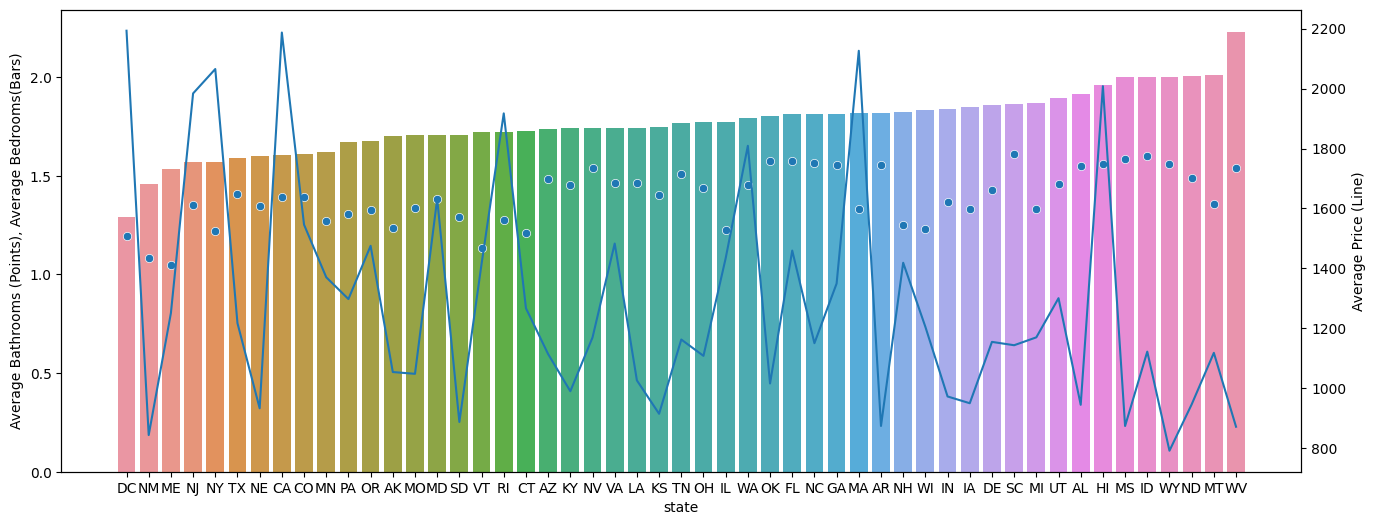

In [10]:
#create derived dataframes using the apts grouped by the interesting column
bathrooms = apts.groupby('state', as_index=False)['bathrooms'].mean().sort_values('bathrooms')
bedrooms = apts.groupby('state', as_index=False)['bedrooms'].mean().sort_values('bedrooms')

#combine the dataframes to include the price
bedrooms_with_price = bedrooms.merge(state_means, how='inner', on='state')
bedrooms_bathrooms_price = bedrooms_with_price.merge(bathrooms, how='inner', on='state')

#create subplots and set figsize to be larger
fig, ax1 = plt.subplots(figsize=(16,6))

#Create a duplicate y-axis for mapping
ax2 = ax1.twinx()

#create BAR plot
sns.barplot(x = 'state', y='bedrooms', data=bedrooms_bathrooms_price, ax=ax1)
ax1.set_ylabel('Average Bathrooms (Points), Average Bedrooms(Bars)')

#create SCATTER plot
sns.scatterplot(x = 'state', y = 'bathrooms',data = bedrooms_bathrooms_price,  ax=ax1)

#add the price data to see how that correlates
sns.lineplot(x = 'state', y = 'price',data = bedrooms_bathrooms_price, ax=ax2)
ax2.set_ylabel('Average Price (Line)')

#show the plot
plt.show()

### Bedroom:Bathroom Ratio and Price

I am interested in seeing the correlation between the bedroom/bathroom ratio in an apartment and how it relates to price by state. The first thing to do is to create a new column in bedrooms_bathrooms_price called **bedbathratio** which is simply the number of bedrooms over the number of bathrooms. Then we can sort by price and see how that correlates to the ratio we generated. 

There does not appear to be a significant correlation between these two facts. This suggests that other features of the apartment, like square feet and amenities have a greater impact than this individual ratio.

Text(0, 0.5, 'Price')

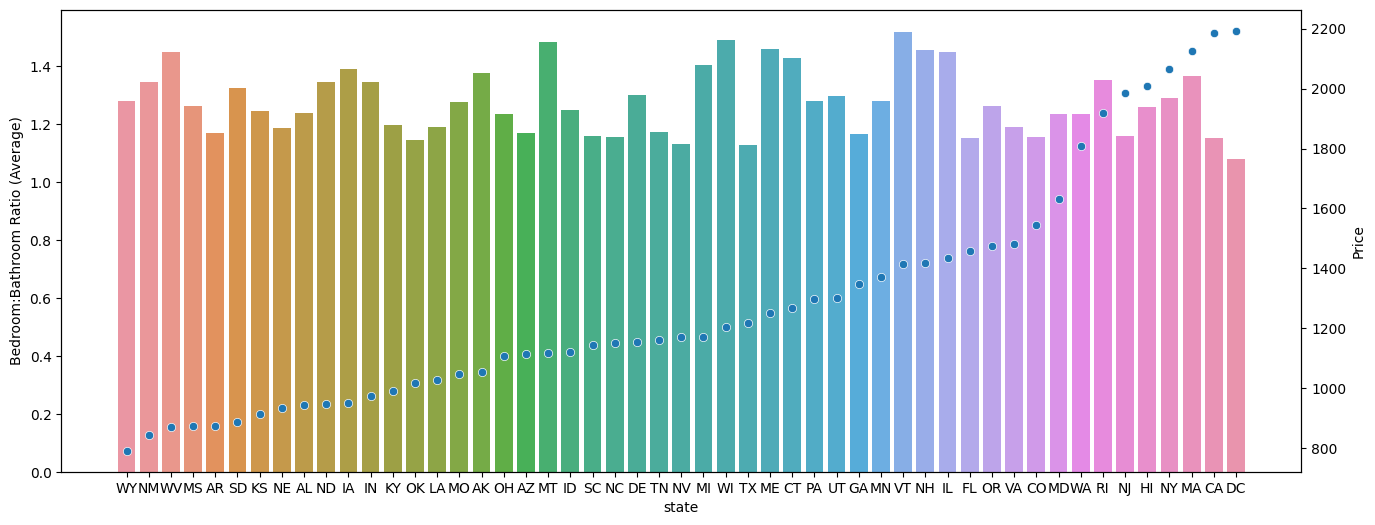

In [11]:
bedrooms_bathrooms_price['bedbathratio'] = bedrooms_bathrooms_price['bedrooms']/bedrooms_bathrooms_price['bathrooms']
bedrooms_bathrooms_price = bedrooms_bathrooms_price.sort_values('price')

#create subplots and set figsize to be larger
fig, ax1 = plt.subplots(figsize=(16,6))

#Create a duplicate y-axis for mapping
ax2 = ax1.twinx()

#create BAR plot
sns.barplot(x = 'state', y='bedbathratio', data=bedrooms_bathrooms_price, ax=ax1)
ax1.set_ylabel('Bedroom:Bathroom Ratio (Average)')

#create SCATTER plot
sns.scatterplot(x = 'state', y = 'price',data = bedrooms_bathrooms_price,  ax=ax2)
ax2.set_ylabel('Price')

## Square Feet

Continuing a trend that will come as no surprise, the most expensive places to live also tend to have the highest cost in dollars per square foot of apartment space. So, in most cases, you can get the most square feet of apartment, at the best price, in states outside of these high demand states. This stands to reason! An interesting note though, is that in addition to having the highest dollar per square foot ration, DC also offers the smallest average square feet in apartments to begin with.

Text(0, 0.5, 'Average Square Feet')

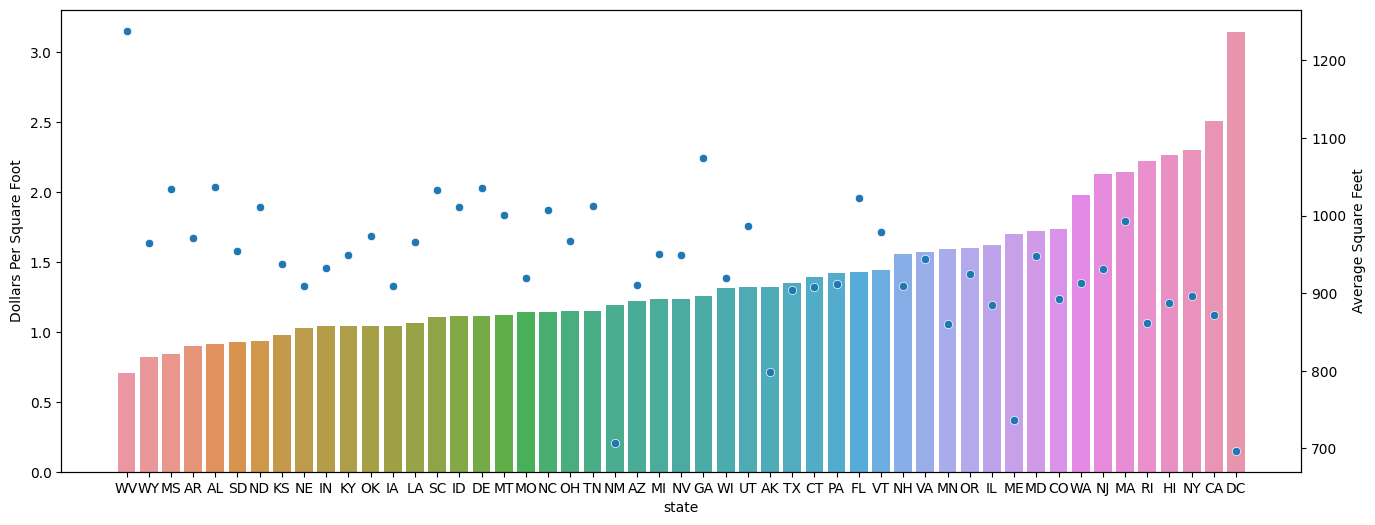

In [12]:
# create dataframe
sqft_apts = apts.groupby('state', as_index=False)['square_feet'].mean()

#merge with our state_means dataset
sqft_apts = sqft_apts.merge(state_means, how='inner', on='state')

#square feet per dollar column creation
sqft_apts['dollar_per_sqft'] = sqft_apts['price']/sqft_apts['square_feet']
sqft_apts = sqft_apts.sort_values('dollar_per_sqft')

#create BAR plot
fig, ax1 = plt.subplots(figsize=(16,6))
sns.barplot(x = 'state', y='dollar_per_sqft', data=sqft_apts)
ax1.set_ylabel('Dollars Per Square Foot')

#Create a duplicate y-axis for mapping
ax2 = ax1.twinx()

#create SCATTER plot
sns.scatterplot(x = 'state', y = 'square_feet',data = sqft_apts,  ax=ax2)
ax2.set_ylabel('Average Square Feet')

## Amenities 

To better understand the sort of things that are lsited for apartments, we should dive into the amenities listed in our amenities column. This will eventually allow us to dive deeper when creating our model, because these will need to become dummy columns with true / false values instead of their current strings, because the model cannot fit data that isn't in Boolean or Numerical format. 

In [13]:
#analyze the category of data we have
apts['amenities'].value_counts()

amenities
noamenities                                                                          15568
Parking                                                                               6106
Parking,Storage                                                                       2092
Gym,Pool                                                                              1854
Pool                                                                                  1455
                                                                                     ...  
Hot Tub,Parking,Patio/Deck,Washer Dryer                                                  1
Basketball,Clubhouse,Gym,TV,Tennis                                                       1
Clubhouse,Fireplace,Gated,Gym,Hot Tub,Parking,Patio/Deck,Pool,Tennis,Washer Dryer        1
Basketball,Dishwasher,Elevator,Gym,Parking,Washer Dryer                                  1
Dishwasher,Doorman,Patio/Deck,Refrigerator,Storage,Washer Dryer,Wood Floors     

#### Wordcloud

There are over 9600 different combinations in our 100,000 (now reduced by filtering and error correction) apartment dataset, so we will need to do some reduction of complexity, and get specifically the words that are used to describe amenities, and then make columns for this. Because this is the majority of the process of creating a wordcloud, I will go ahead and finish that process and generate a wordcloud to explore what the most common terms are in relation to each other.

To do this, we will 'explode' out the entries of each column and put them into a big list, split by the comma character. Then we will count the occurences of each word, and use the Python Wordcloud library to analyze and generate the data tied to this.

amenities
Parking               43189
Pool                  42940
Gym                   36836
Patio/Deck            26061
Washer Dryer          25678
Storage               21381
Clubhouse             18903
Dishwasher            16335
noamenities           15568
AC                    15559
Fireplace             14692
Refrigerator          14631
Cable or Satellite    12369
Playground            11250
Internet Access       10932
Wood Floors            8606
Gated                  8522
Tennis                 8351
TV                     4401
Elevator               4182
Basketball             4119
Hot Tub                3932
Garbage Disposal       3845
View                   2028
Alarm                   354
Luxury                  204
Doorman                 175
Golf                     27
Name: count, dtype: int64


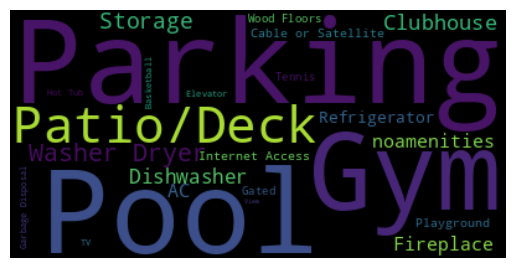

In [14]:
#'explode' our column out to all the individual entries
text = apts['amenities'].str.split(',').explode()
print(text.value_counts())

#generate word cloud from text as a dict
wordcloud_data = text.value_counts().to_dict()
wordcloud = WordCloud().generate_from_frequencies(wordcloud_data)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Overall Regression

I like to analyze dataframes as ccomparisons of each feature against our y-value. Below I use the regression analysis function to do this. We will strictly be looking at a subset of the apts dataframe, the values which are already numerical and not categoricals or true / false. One of the interesting things about this is the p-values are so small that even adding floats for six points results in a 0 value, suggesting that all these things are important to the price and reject the null hypothesis that they do not have a bearing on price.

In [15]:
pd.options.display.float_format = "{:,.6f}".format
print(regression_analysis(apts[['bathrooms','bedrooms','price', 'square_feet','latitude','longitude']], "price"))
pd.options.display.float_format = "{:,.2f}".format

           bathrooms  bedrooms    price  square_feet  latitude  longitude
slope       0.000239  0.000243 1.000000     0.174747  0.000841  -0.002130
intercept   1.083784  1.360643 0.000000   689.204946 35.721751 -88.282670
rvalue      0.283372  0.207806 1.000000     0.328280  0.115329  -0.085538
p-value     0.000000  0.000000 0.000000     0.000000  0.000000   0.000000
stderr      0.000003  0.000004 0.000000     0.001608  0.000023   0.000079


## Categorical Encoding

Categorical data cannot be used in a machine learning algorithm until it is turned into numerical data -- or in this case, a series of true/false columns. So here we will encode our colums with categorical data, but first we should analyze the categories we have in our data.

##### Categorical Columns for Amenities

We will need the following columns to convert to true/false (actually, 1 or 0, 1 for True, 0 for False) for use in our analysis.

Based on the value_counts, we know that we can break down amenities to these:

*Parking, Pool, Gym, Patio/Deck, Washer Dryer, Storage, Clubhouse, Dishwasher, AC, Refrigerator, Fireplace, Cable or Satellite, Playground, Wood Floors, Gated, Tennis, TV, Elevator, Basketball, Hot Tub, Garbage Disposal, View, Alarm, Doorman, Luxury, Golf*

In [16]:
apts = make_dummies(apts, 'amenities')
print(apts.columns.tolist())
apts

['bathrooms', 'bedrooms', 'fee', 'has_photo', 'pets_allowed', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time', 'AC', 'Alarm', 'Basketball', 'Cable or Satellite', 'Clubhouse', 'Dishwasher', 'Doorman', 'Elevator', 'Fireplace', 'Garbage Disposal', 'Gated', 'Golf', 'Gym', 'Hot Tub', 'Internet Access', 'Luxury', 'Parking', 'Patio/Deck', 'Playground', 'Pool', 'Refrigerator', 'Storage', 'TV', 'Tennis', 'View', 'Washer Dryer', 'Wood Floors', 'noamenities']


,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,noamenities
id,,,,,,,,,,,,,,,,,,,,,
5668640009,1.00,1.00,No,Thumbnail,Cats,"2,195.00",542,Redondo Beach,CA,33.85,...,0,0,0,0,0,0,0,0,0,1
5668639818,1.50,3.00,No,Thumbnail,"Cats,Dogs","1,250.00",1500,Newport News,VA,37.09,...,0,0,0,0,0,0,0,0,0,1
5668639686,2.00,3.00,No,Thumbnail,None,"1,395.00",1650,Raleigh,NC,35.82,...,0,0,0,0,0,0,0,0,0,1
5668639659,1.00,2.00,No,Thumbnail,"Cats,Dogs","1,600.00",820,Vacaville,CA,38.36,...,0,0,0,0,0,0,0,0,0,1
5668639374,1.00,1.00,No,Thumbnail,"Cats,Dogs",975.00,624,Albuquerque,NM,35.10,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5121219946,1.00,1.00,No,Yes,None,780.00,605,Houston,TX,29.62,...,1,0,0,1,0,0,0,0,1,0
5121219696,2.00,2.00,No,Yes,"Cats,Dogs",813.00,921,Jacksonville,FL,30.23,...,1,1,1,1,1,0,0,1,0,0
5121219420,1.00,1.00,No,Yes,"Cats,Dogs","1,325.00",650,San Diego,CA,32.74,...,0,0,1,0,0,0,0,0,0,0



#### Pets

Next, we need to do the same operation, but this time using Pets. We will use the function built for this purpose, make_dummies, because it works much better than other options I investigated and with less work.

In [17]:
apts = make_dummies(apts,'pets_allowed')
print(apts.columns.tolist())
apts

['bathrooms', 'bedrooms', 'fee', 'has_photo', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time', 'AC', 'Alarm', 'Basketball', 'Cable or Satellite', 'Clubhouse', 'Dishwasher', 'Doorman', 'Elevator', 'Fireplace', 'Garbage Disposal', 'Gated', 'Golf', 'Gym', 'Hot Tub', 'Internet Access', 'Luxury', 'Parking', 'Patio/Deck', 'Playground', 'Pool', 'Refrigerator', 'Storage', 'TV', 'Tennis', 'View', 'Washer Dryer', 'Wood Floors', 'noamenities', 'Cats', 'Dogs', 'None']


,bathrooms,bedrooms,fee,has_photo,price,square_feet,cityname,state,latitude,longitude,...,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,noamenities,Cats,Dogs,None
id,,,,,,,,,,,,,,,,,,,,,
5668640009,1.00,1.00,No,Thumbnail,"2,195.00",542,Redondo Beach,CA,33.85,-118.38,...,0,0,0,0,0,0,1,1,0,0
5668639818,1.50,3.00,No,Thumbnail,"1,250.00",1500,Newport News,VA,37.09,-76.49,...,0,0,0,0,0,0,1,1,1,0
5668639686,2.00,3.00,No,Thumbnail,"1,395.00",1650,Raleigh,NC,35.82,-78.64,...,0,0,0,0,0,0,1,0,0,1
5668639659,1.00,2.00,No,Thumbnail,"1,600.00",820,Vacaville,CA,38.36,-121.97,...,0,0,0,0,0,0,1,1,1,0
5668639374,1.00,1.00,No,Thumbnail,975.00,624,Albuquerque,NM,35.10,-106.61,...,0,0,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5121219946,1.00,1.00,No,Yes,780.00,605,Houston,TX,29.62,-95.20,...,1,0,0,0,0,1,0,0,0,1
5121219696,2.00,2.00,No,Yes,813.00,921,Jacksonville,FL,30.23,-81.76,...,1,1,0,0,1,0,0,1,1,0
5121219420,1.00,1.00,No,Yes,"1,325.00",650,San Diego,CA,32.74,-117.09,...,0,0,0,0,0,0,0,1,1,0


#### Has Fee Data, Has Photo Data

This one is a little quicker and easier -- convert has fee to be a True/False column and convert to datatype bool. This will reduce the complexity of the model from its previous values and does not require the generation of new columns.

##### Verify Changes

We will also take a step to verify the changes we made in this step.

In [18]:
apts.fee.map({"Yes":1,"No":0})
apts.has_photo.map({"Yes":1,"Thumbnail":1,"No":0})
apts = apts.astype({"fee": bool, "has_photo": bool})
display(apts)
print(apts.info(verbose=True))

,bathrooms,bedrooms,fee,has_photo,price,square_feet,cityname,state,latitude,longitude,...,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,noamenities,Cats,Dogs,None
id,,,,,,,,,,,,,,,,,,,,,
5668640009,1.00,1.00,True,True,"2,195.00",542,Redondo Beach,CA,33.85,-118.38,...,0,0,0,0,0,0,1,1,0,0
5668639818,1.50,3.00,True,True,"1,250.00",1500,Newport News,VA,37.09,-76.49,...,0,0,0,0,0,0,1,1,1,0
5668639686,2.00,3.00,True,True,"1,395.00",1650,Raleigh,NC,35.82,-78.64,...,0,0,0,0,0,0,1,0,0,1
5668639659,1.00,2.00,True,True,"1,600.00",820,Vacaville,CA,38.36,-121.97,...,0,0,0,0,0,0,1,1,1,0
5668639374,1.00,1.00,True,True,975.00,624,Albuquerque,NM,35.10,-106.61,...,0,0,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5121219946,1.00,1.00,True,True,780.00,605,Houston,TX,29.62,-95.20,...,1,0,0,0,0,1,0,0,0,1
5121219696,2.00,2.00,True,True,813.00,921,Jacksonville,FL,30.23,-81.76,...,1,1,0,0,1,0,0,1,1,0
5121219420,1.00,1.00,True,True,"1,325.00",650,San Diego,CA,32.74,-117.09,...,0,0,0,0,0,0,0,1,1,0


<class 'pandas.core.frame.DataFrame'>
Index: 97720 entries, 5668640009 to 5121218844
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bathrooms           97720 non-null  Float32
 1   bedrooms            97720 non-null  Float32
 2   fee                 97720 non-null  bool   
 3   has_photo           97720 non-null  bool   
 4   price               97720 non-null  Float64
 5   square_feet         97720 non-null  Int64  
 6   cityname            97720 non-null  string 
 7   state               97720 non-null  string 
 8   latitude            97720 non-null  Float64
 9   longitude           97720 non-null  Float64
 10  source              97720 non-null  string 
 11  time                97720 non-null  Int64  
 12  AC                  97720 non-null  int64  
 13  Alarm               97720 non-null  int64  
 14  Basketball          97720 non-null  int64  
 15  Cable or Satellite  97720 non-null  int64  


## Post Catagorical Analysis

Lets evaluate the relationships between the categorical columns and the resultant price, now that they have been encoded.

In [19]:
pd.options.display.float_format = "{:,.6f}".format
regression = regression_analysis(apts[apts.columns.difference(['cityname','state','source'])], "price")
with pd.option_context('display.max_rows', 5, 'display.max_columns', None): 
    display(regression)
pd.options.display.float_format = "{:,.2f}".format

,AC,Alarm,Basketball,Cable or Satellite,Cats,Clubhouse,Dishwasher,Dogs,Doorman,Elevator,Fireplace,Garbage Disposal,Gated,Golf,Gym,Hot Tub,Internet Access,Luxury,None,Parking,Patio/Deck,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,bathrooms,bedrooms,fee,has_photo,latitude,longitude,noamenities,price,square_feet,time
slope,-0.000029,0.000000,-0.000012,-0.000036,-0.000040,-0.000045,-0.000043,-0.000034,0.000003,0.000033,-0.000018,-0.000026,0.000007,0.000000,0.000023,0.000006,-0.000015,0.000001,0.000039,0.000021,-0.000006,-0.000067,-0.000022,-0.000046,-0.000007,0.000007,-0.000026,0.000011,-0.000035,0.000044,0.000239,0.000243,0.000000,0.000000,0.000841,-0.002130,0.000013,1.000000,0.174747,834.294246
intercept,0.201980,0.003323,0.059381,0.179191,0.452191,0.259253,0.230332,0.426048,-0.003137,-0.006227,0.176805,0.077849,0.076793,0.000253,0.343530,0.031496,0.133786,0.001181,0.548295,0.411540,0.276120,0.214033,0.471815,0.217983,0.228431,0.034863,0.123560,0.004342,0.314409,0.023639,1.083784,1.360643,1.000000,1.000000,35.721751,-88.282670,0.140100,0.000000,689.204946,"1,558,368,853.596301"
rvalue,-0.050156,0.002139,-0.036801,-0.067911,-0.052055,-0.071505,-0.072659,-0.044778,0.050024,0.103948,-0.031769,-0.084990,0.015842,0.000590,0.029600,0.019091,-0.029838,0.008528,0.050559,0.026293,-0.009150,-0.132992,-0.028013,-0.082103,-0.009999,0.021054,-0.058490,0.049405,-0.050350,0.097569,0.283372,0.207806,0.000000,0.000000,0.115329,-0.085538,0.022530,1.000000,0.328280,0.047646
p-value,0.000000,0.503728,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000001,0.853620,0.000000,0.000000,0.000000,0.007682,0.000000,0.000000,0.004230,0.000000,0.000000,0.000000,0.001773,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
stderr,0.000002,0.000000,0.000001,0.000002,0.000002,0.000002,0.000002,0.000002,0.000000,0.000001,0.000002,0.000001,0.000001,0.000000,0.000002,0.000001,0.000002,0.000000,0.000002,0.000003,0.000002,0.000002,0.000003,0.000002,0.000002,0.000001,0.000001,0.000001,0.000002,0.000001,0.000003,0.000004,0.000000,0.000000,0.000023,0.000079,0.000002,0.000000,0.001608,55.951711


In [20]:
column_list = regression.columns.values.tolist()
feature_average_price_dict = {}
for c in column_list:
    temp = apts.loc[apts[c] == 1]
    feature_average_price_dict[c] = temp.price.mean()
average_price_by_feature = pd.DataFrame.from_dict(feature_average_price_dict, orient='index')
average_price_by_feature = average_price_by_feature.sort_values(by=0, ascending = False)
print(average_price_by_feature)

                          0
Doorman            2,213.78
Elevator           1,779.09
View               1,683.11
Wood Floors        1,667.09
Luxury             1,586.69
TV                 1,530.26
Hot Tub            1,527.92
noamenities        1,501.77
Gated              1,501.45
None               1,494.84
Gym                1,493.13
Golf               1,491.52
Alarm              1,491.50
Parking            1,487.76
has_photo          1,469.13
fee                1,469.13
Patio/Deck         1,459.57
Storage            1,457.22
Pool               1,449.18
Dogs               1,432.73
Cats               1,428.34
Fireplace          1,421.52
Internet Access    1,416.13
Washer Dryer       1,415.96
AC                 1,396.47
Clubhouse          1,377.08
Dishwasher         1,366.88
Basketball         1,358.53
Cable or Satellite 1,356.66
Tennis             1,348.49
Refrigerator       1,345.77
bedrooms           1,337.90
bathrooms          1,328.57
Playground         1,236.66
Garbage Disposal   1

### Amenities and Average Price

As we can see, there is some interesting things in our data regarding individual amenities and their influence on price.

 - Alarm, Golf, fee, has_photo do not seem to be significant indfluencers of the price
 - Luxury, Storage, and Patio/Deck seem to have the least likelihood of influencing price, but also very small accompanying R values
 - Doorman, Elevator, View, and Wood Floors are the highest mean prices, indicating these are likely to get a better price.
 
One thing we can use this information for is to determine what upgrades we would like to make to an apartment to increase its rentt.

#### One Hot Encoding? The City and Source Question

Because of the number of city and sources, I could use the one hot encoding feature to make this more digestable for our model. ***Alternatively***, the latitude and longitude, which are already stand-ins for location, can be used. It would probably work better to encode them as locations on a sphere (the earth) using Geohashing, as described [in this post](https://datascience.stackexchange.com/questions/49553/combining-latitude-longitude-position-into-single-feature). 

I've opted to not include the source in fitting the model -- I do not think it is important that the source be considered because most landlords will list on multiple sources and this can create a significant amount of noise into the model and complexity that isn't neccessary to look at the trends of apartment prices.

In [21]:
#print all unique entries for our categorical data
print(apts['cityname'].unique(), apts['state'].unique(), apts['source'].unique())

<StringArray>
[    'Redondo Beach',      'Newport News',           'Raleigh',
         'Vacaville',       'Albuquerque',           'Hampton',
          'Lakewood',        'Charleston',        'Chatsworth',
        'Alpharetta',
 ...
 'Thompsons Station',            'Roseau',      'Mount Juliet',
              'Napa',        'Prattville',        'Nottingham',
     'Granada Hills',             'Osseo',            'Vestal',
       'Albertville']
Length: 2956, dtype: string <StringArray>
['CA', 'VA', 'NC', 'NM', 'CO', 'WV', 'GA', 'MA', 'DC', 'IA', 'WA', 'TX', 'IL',
 'MS', 'OR', 'FL', 'MO', 'PA', 'WI', 'OK', 'UT', 'RI', 'NJ', 'IN', 'MD', 'OH',
 'TN', 'ND', 'NE', 'AR', 'MI', 'AZ', 'MN', 'ID', 'SC', 'KS', 'AL', 'SD', 'NY',
 'KY', 'LA', 'AK', 'HI', 'CT', 'NV', 'WY', 'VT', 'NH', 'MT', 'DE', 'ME']
Length: 51, dtype: string <StringArray>
[        'RentLingo',         'ListedBuy',      'RentDigs.com',
          'RENTCafé',        'GoSection8',          'Listanza',
       'RealRentals',        'REN

I would have used the methodology described by [this article](https://www.geeksforgeeks.org/ml-one-hot-encoding/) to create a vectory array of the categorical values in the data. Because our data that is not able to be processed in the model is just 'string' data type, it will select from the dataset all columns with string datatype. **Doing this will generate 3000 columns in the vector array when we are done**. This is a large increase in complexity, and perhaps it won't have implications on accuracy (though I suspect this isn't the case) if we remove this complicated facet from analysis by our model. ***Because location is really just latitude, longitude I am OK with using that numerical value to build the model instead of creating this level of complexity***.

# Model Creation

The first step in this data set is to wrangle our features into something that we can use in our model, meaning the categorical values need to be encoded somehow. This becomes more challenging when you look at the complexity of the amenities, pets, cities, fee status, and sources columns. Creating new columns to encode this data for all of these could bloat the size of our dataframe and slow down modeling and processing significantly. However, we can use the pandas make dummies function to split up the ones that are most import for analyzing data. I believe that this data is the amenities column and the pets column.

## Model Definitions

For our initial model, lets use every column besides price as our features, except for cityname, source, and state, and see how the model performs.

**column_list** - all of the columns from our data except our desired y value, price, and the aforementioned exclusions.

**X** - the feature list, which is built from the column_list variable we declare. This could be combined, but I like to make these steps more explicit in long form work like this.

**y** - we will redeclare y so that it matches our conditioned data set -- the intial dataset has changed since we started and it is better to be explicit (and safe)

In [22]:
#Create X and y for our model, remove the categorical
column_list = apts[apts.columns.difference(['price', 'cityname','state','source'])].columns.tolist()

print(column_list)
print(len(column_list))

X = apts[column_list]
y = apts.price

['AC', 'Alarm', 'Basketball', 'Cable or Satellite', 'Cats', 'Clubhouse', 'Dishwasher', 'Dogs', 'Doorman', 'Elevator', 'Fireplace', 'Garbage Disposal', 'Gated', 'Golf', 'Gym', 'Hot Tub', 'Internet Access', 'Luxury', 'None', 'Parking', 'Patio/Deck', 'Playground', 'Pool', 'Refrigerator', 'Storage', 'TV', 'Tennis', 'View', 'Washer Dryer', 'Wood Floors', 'bathrooms', 'bedrooms', 'fee', 'has_photo', 'latitude', 'longitude', 'noamenities', 'square_feet', 'time']
39


### Test Leaf Nodes

Now we are ready to run our model on the collected dataset, minus its categorical data. Because of the size of this data and the number of calulations involved, this model takes a while to run -- and running the leaf node analysis can take a very long time as well.<br>

***For the sake of saving time on running the workbook, I have included the results of my leaf node analysis in this markdown, and commented out the leaf node analysis process after picking the 'best' value.***

`Max leaf nodes: 100  		 Mean Absolute Error:  259.771550
Max leaf nodes: 125  		 Mean Absolute Error:  252.368323
Max leaf nodes: 150  		 Mean Absolute Error:  246.497292
Max leaf nodes: 175  		 Mean Absolute Error:  241.530385
Max leaf nodes: 200  		 Mean Absolute Error:  237.374581
Max leaf nodes: 225  		 Mean Absolute Error:  233.982300
Max leaf nodes: 300  		 Mean Absolute Error:  225.978388
Max leaf nodes: 350  		 Mean Absolute Error:  221.835462
Max leaf nodes: 400  		 Mean Absolute Error:  218.304372`

...

`Max leaf nodes: 3500  		 Mean Absolute Error:  164.084618
Max leaf nodes: 3750  		 Mean Absolute Error:  162.542098
Max leaf nodes: 4000  		 Mean Absolute Error:  161.147271
Max leaf nodes: 4250  		 Mean Absolute Error:  159.910808
Max leaf nodes: 4500  		 Mean Absolute Error:  158.736361
`
<br>...<br>
`
Max leaf nodes: 12500  		 Mean Absolute Error:  143.115326
Max leaf nodes: 13000  		 Mean Absolute Error:  142.799924
Max leaf nodes: 13500  		 Mean Absolute Error:  142.515858
Max leaf nodes: 14000  		 Mean Absolute Error:  142.257499`

Based on model performance, I decided that +/-$150 was a pretty good mean absolute error, its about 10% of the total average rental price. 

In [23]:
#create a list of leaf node tests we would like to run
#leaf_test = range(15000)[10000::500]

#Create training variables and set random state, using the train_test_split function
#train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=23)

#run the simulation quickly and determine which value of leaf nodes creates the best MAE
#best_leaf_nodes = calc_best_leaf_nodes(leaf_test, train_X, val_X, train_y, val_y)
#print("Best Leaf Nodes Value Located: ", best_leaf_nodes)

## Formal Model Creation

This is the moment of truth -- the actual model is created in this step, and ready to start fitting new data for price results. We will use the RandomForestRegressor and the max_leaf_nodes value of 5000 discovered in the last step.

In [24]:
model = RandomForestRegressor(max_leaf_nodes=5000, random_state=23)
model.fit(X, y)

RandomForestRegressor(max_leaf_nodes=5000, random_state=23)

## Predictive Analysis - How Well Does it Work?

The next step is to run our data against the smaller data set and see if we have over-fit. We will need to perform all the adjustments we made in the large dataset to the smaller one and then make it into a list of features (val_X) and the final "correct" y values to use to calculate mean absolute error.

### Validation Data Creation

I have collected all updates made to the base apartment dataset here and applied them to our smaller dataset to condition it for use as a validation set. These changes are:

- create the noamenities category for dummy filling
- create the none category for pets for dummy filling
- fill in na values and filter out the odd '0' state
- condition state and cityname to string for speed
- filter out all apartments over 4000 a month
- create the dummy columns
- update other columns to be true/false (fees, has_picture)
- **final_val_y** the price data in case we need to reference it for validation
- finally, remove all unneeded columns from small_apts

In [25]:
print("Before\n")
print(small_apts.info())

#create 'noamenities' as a category, for use in later dummy creation
small_apts['amenities'] = small_apts["amenities"].fillna("noamenities")

#create 'none' for 'pets_allowed' for use in later dummy creation
small_apts["pets_allowed"] = small_apts["pets_allowed"].fillna("None")

#Instead of interpreting weird results, like no number of bathrooms or no numbers of bedrooms, we will drop those data points
#this also includes 'state = 0' an odd result that I've seen come up later in analysis
small_apts = small_apts[small_apts['bathrooms'].notna()]
small_apts = small_apts[small_apts['bedrooms'].notna()]
small_apts = small_apts[small_apts['price'].notna()]
small_apts = small_apts[small_apts['latitude'].notna()]
small_apts = small_apts[small_apts['longitude'].notna()]
small_apts = small_apts[small_apts['cityname'].notna()]
small_apts = small_apts[small_apts['state'].notna()]
small_apts = small_apts[small_apts.state != 0]

#change datatype of state to string, no real reason other than i don't trust objects
small_apts['state'] = small_apts['state'].astype("string")
small_apts['cityname'] = small_apts['cityname'].astype("string")

#remove outliers and odd data for our y
small_apts = small_apts[small_apts.price < 4000]

#create dummy columns
small_apts = make_dummies(small_apts, 'amenities')
print(small_apts.columns.tolist())

#update pets allowed to follow standards
small_apts = make_dummies(small_apts,'pets_allowed')
print(apts.columns.tolist())

#update other columns to be yes/no
small_apts.fee.map({"Yes":1,"No":0})
small_apts.has_photo.map({"Yes":1,"Thumbnail":1,"No":0})
small_apts = small_apts.astype({"fee": bool, "has_photo": bool})

#create our validation X list
final_val_y = small_apts.price
small_apts = small_apts[small_apts.columns.difference(['price','cityname','state','source'])]

#Check to make sure we no longer have a difference between entries and nulls
print("After\n")
print(small_apts.info())

print(small_apts.describe())

Before

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 5668626895 to 5509132540
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amenities     6451 non-null   string 
 1   bathrooms     9966 non-null   Float32
 2   bedrooms      9993 non-null   Float32
 3   fee           10000 non-null  string 
 4   has_photo     10000 non-null  string 
 5   pets_allowed  5837 non-null   string 
 6   price         10000 non-null  Float64
 7   square_feet   10000 non-null  Int64  
 8   cityname      9923 non-null   object 
 9   state         9923 non-null   object 
 10  latitude      9990 non-null   Float64
 11  longitude     9990 non-null   Float64
 12  source        10000 non-null  string 
 13  time          10000 non-null  string 
dtypes: Float32(2), Float64(3), Int64(1), object(2), string(6)
memory usage: 1.1+ MB
None
['bathrooms', 'bedrooms', 'fee', 'has_photo', 'pets_allowed', 'price', 'square_feet', 'cityname'

## Validation Execution

Now we will create a validation test for our model from the dataset we just conditioned. **pred_val** will be the result of predicted values from the small_apts dataset run through the model. Then we will calculate the mean absolute error and print out the result to see how it performed.

In [26]:
preds_val = model.predict(small_apts)
mae = mean_absolute_error(final_val_y, preds_val)
print(mae)

132.3220464665398


The result is 132.32 mean absolute error, our model performs well! Even better than it performed in our validation trial, which comes as a surprise to me. This magnitude of error is acceptable -- we've all seen prices listed for +/-65 where they should be and that amounts to very little in the long run for apartments that are likely to be upwards of \$1000 a month.